# Download Data

In [1]:
import pandas as pd

df = pd.read_parquet('../data/Player-Games_Injuries_Travel_Bio.parquet')
print(df['injury_within_14d'].value_counts(normalize=True))
df = df.drop(columns=['days_to_next_injury', 'injury_within_7d',
                      'injury_within_14d',
                      'injury_within_30d' , 'coachId'])
df.head()

injury_within_14d
0    0.893147
1    0.106853
Name: proportion, dtype: float64


,personId,gameId,gameDateTimeEst_player,playerteamName,gameType_player,win_player,home_player,numMinutes_player,points_player,assists_player,...,direction_ew,tz_shift_hrs,rest_days,flight_minutes,height,weight,birthdate,experience,bmi,age
0,255.0,21000521,2011-01-05 22:30:00,Suns,Regular Season,0.0,1.0,34.0,10.0,2.0,...,East,1.0,2.0,69.3,80.0,225.0,1972-10-05,18,24.714844,38.250513
1,255.0,21000533,2011-01-07 22:30:00,Suns,Regular Season,0.0,1.0,29.0,10.0,2.0,...,N/A,0.0,1.0,0.0,80.0,225.0,1972-10-05,18,24.714844,38.255989
2,255.0,21000584,2011-01-14 22:30:00,Suns,Regular Season,1.0,1.0,36.0,21.0,3.0,...,N/A,0.0,1.0,0.0,80.0,225.0,1972-10-05,18,24.714844,38.275154
3,255.0,21000598,2011-01-17 13:00:00,Suns,Regular Season,1.0,0.0,37.0,25.0,2.0,...,East,2.0,2.0,234.0,80.0,225.0,1972-10-05,18,24.714844,38.283368
4,255.0,21000613,2011-01-19 19:00:00,Suns,Regular Season,1.0,0.0,40.0,27.0,2.0,...,West,0.0,1.0,44.1,80.0,225.0,1972-10-05,18,24.714844,38.288843


# Combine with the Injury then Exclude Non-Injuries

In [2]:
with open('../data/Non-Basketball Injuries.txt', 'r') as f:
    non_bball = set(line.strip() for line in f if line.strip())
injuries = pd.read_csv('../data/injury_data.csv')
injuries = injuries[~injuries['Injury'].isin(non_bball)].copy()

In [3]:
name_fixes = {
  'pj washington': 'p.j. washington',
  'aleksandar vezenkov': 'sasha vezenkov',
  'moe harkless': 'maurice harkless',
  'cameron thomas': 'cam thomas',
  'greg brown': 'greg brown iii',
  'nicolas claxton': 'nic claxton',
  'rj nembhard': 'rj nembhard jr.',
  'tj leaf': 't.j. leaf',
  'j.r. smith': 'jr smith',
  'robert williams': 'rob williams',
  'michael frazier': 'michael frazier ii',
  'rj hampton': 'r.j. hampton',
  'jabari smith jr': 'jabari smith jr.',
  'vernon carey jr': 'vernon carey jr.',
  'brandon boston jr': 'brandon boston jr.',
  'goga bitadze': 'ga bitadze'
}

injuries["PLAYER_clean"] = injuries["PLAYER"].astype(str).str.strip().str.lower()
injuries['PLAYER_clean'] = injuries['PLAYER_clean'].replace(name_fixes)
set_df = set(df["Name"])
set_inj = set(injuries["PLAYER_clean"])

common = set_df & set_inj
only_df = set_df - set_inj
only_inj = set_inj - set_df

print("common:", len(common))
print("df only:", len(only_df))
print("inj only:", len(only_inj))

common: 676
df only: 996
inj only: 8


In [4]:
import numpy as np

injuries["INJURED ON"] = pd.to_datetime(injuries["INJURED ON"], errors="coerce")
injuries["season"] = np.where(
    injuries["INJURED ON"].dt.month >= 10,
    injuries["INJURED ON"].dt.year + 1,
    injuries["INJURED ON"].dt.year
)
injuries.loc[
    (injuries['INJURED ON'] >= '2020-10-01') & (injuries['INJURED ON'] <= '2020-12-01'),
    'season'
] = 2020

injuries = injuries.dropna(subset=["INJURED ON"])

injury_arr = injuries[["PLAYER_clean", "season", "INJURED ON"]].values

In [5]:
from collections import defaultdict

injury_map = defaultdict(list)

for p, s, d in injury_arr:
    injury_map[(p, s)].append(d)

for k in injury_map:
    injury_map[k] = np.sort(np.array(injury_map[k], dtype="datetime64[D]"))

injury_name_map = defaultdict(lambda: defaultdict(list))
for _, row in injuries.iterrows():
    injury_name_map[(row['PLAYER_clean'], row['season'])][
        np.datetime64(row['INJURED ON'], 'D')
    ].append(row['Injury'])

In [6]:
# Build a minimal temp df with only basketball injury flags
temp_results = []
for name, group in df.groupby('Name', sort=False):
    group = group.sort_values('gameDateTimeEst_player')
    games   = group['gameDateTimeEst_player'].values.astype('datetime64[D]')
    seasons = group['season_x'].values
    n = len(games)

    w14 = np.zeros(n, dtype=np.int8)
    injury_names_14d = [[] for _ in range(n)]

    for i in range(n):
        inj = injury_map.get((name, seasons[i]))
        if inj is None:
            continue
        j = np.searchsorted(inj, games[i], side='right')
        if j >= len(inj):
            continue
        delta = (inj[j] - games[i]).astype(int)
        w14[i] = delta <= 14
        if delta <= 14:
            for inj_date in inj[j:]:
                d = (inj_date - games[i]).astype(int)
                if d <= 14:
                    injury_names_14d[i].extend(injury_name_map[(name, seasons[i])][inj_date])
                else:
                    break

    temp_results.append(pd.DataFrame({
        'Name': name,
        'gameDateTimeEst_player': group['gameDateTimeEst_player'].values,
        'injury_within_14d': w14,
        'Injuries': injury_names_14d
    }))

temp_df = pd.concat(temp_results, ignore_index=True)

# Merge into df, replace old col
df = df.merge(temp_df, on=['Name', 'gameDateTimeEst_player'], how='left')
df = df.drop(columns=['Name'])
df['Injuries'] = df['Injuries'].apply(lambda x: x if isinstance(x, list) else [])

del temp_df, temp_results

In [7]:
df['Injuries'].value_counts()

Injuries
[]                                          303634
[Sprained left ankle]                         1827
[Sprained right ankle]                        1692
[Sore left knee]                              1056
[Sore right knee]                              951
                                             ...  
[Left knee injury, Lower back injury]            1
[Bruised left knee, Lower back injury]           1
[Hip flexor injury, Concussion]                  1
[Sprained left ankle, Left ankle injury]         1
[Sore back, Sore ribs / back injury]             1
Name: count, Length: 1277, dtype: int64

In [8]:
df['injury_within_14d'].value_counts(normalize=True)

injury_within_14d
0    0.911381
1    0.088619
Name: proportion, dtype: float64

In [9]:
seasons = sorted(df['season_x'].unique())

test_season = seasons[-1]
val_season = seasons[-2]
train_seasons = seasons[:-2]

test_df = df[df['season_x'] == test_season]
val_df = df[df['season_x'] == val_season]
train_df = df[df['season_x'].isin(train_seasons)]

In [10]:
print(len(test_df), len(val_df), len(train_df))
print(test_df['injury_within_14d'].mean())

22937 23295 286926
0.17208004534158783


In [11]:
kept_features = ['rolling_3g_assists', 'rolling_3g_blocks', 'rolling_3g_points',
                 'rolling_7g_rebounds', 'rolling_7g_steals', 'rolling_3g_points_per36',
                 'rolling_3g_three_pointers_made', 'rolling_3g_steals', 'rolling_7g_assists',
                 'rolling_3g_ft_relative_percent', 'winPercent_team', 'rolling_7g_minutes',
                 'rolling_3g_USG', 'rolling_7g_USG', 'rolling_3g_three_point_percent',
                 'rolling_7g_field_goals_made', 'rolling_7g_three_pointers_attempted',
                 'rolling_7g_turnovers', 'rolling_3g_assists_per36', 'rolling_7g_three_pointers_made',
                 'games_last_14d', 'rolling_3g_field_goals_made', 'rolling_3g_three_pointers_attempted',
                 'rolling_7g_points_per36', 'rolling_7g_blocks', 'rolling_7g_assists_per36',
                 'rolling_7g_3p_relative_percent', 'positionless_index', 'rolling_3g_field_goals_attempted',
                 'rolling_3g_3p_relative_percent', 'rolling_7g_three_point_percent', 'rolling_7g_points',
                 'rolling_3g_turnovers', 'rolling_7g_field_goals_attempted']

CatBoost seems to perform the best.

In [12]:
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score
from sklearn.impute import SimpleImputer
from catboost import CatBoostClassifier

target = 'injury_within_14d'
X_sel = df[list(kept_features) + ['season_x']].copy()
y_sel = df[target].values

train_mask = X_sel['season_x'].isin(train_seasons)
val_mask = X_sel['season_x'] == val_season
test_mask = X_sel['season_x'] == test_season

X_train = X_sel.loc[train_mask].drop(columns=['season_x'])
X_val = X_sel.loc[val_mask].drop(columns=['season_x'])
X_test = X_sel.loc[test_mask].drop(columns=['season_x'])

y_train = y_sel[train_mask]
y_val = y_sel[val_mask]
y_test = y_sel[test_mask]

X_full_train = pd.concat([X_train, X_val], axis=0)
y_full_train = np.concatenate([y_train, y_val])

imputer = SimpleImputer(strategy='median')
imputer.set_output(transform="pandas")
X_full_train = imputer.fit_transform(X_full_train)
X_test = imputer.transform(X_test)

model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        verbose=0,
        random_seed=42
    )

model.fit(X_full_train, y_full_train)
preds = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, preds)
auc

0.6257743831411275

In [13]:
baseline = y_test.mean()
baseline

np.float64(0.17208004534158783)

In [14]:
ap = average_precision_score(y_test, preds)
ap

0.25472529538995325

In [15]:
probs = pd.DataFrame({
    "y": y_test,
    "p": preds
}).sort_values("p", ascending=False)

for pct in [1, 5, 10, 20]:
    n = int(len(probs) * pct / 100)
    precision = probs.head(n)["y"].mean()
    print(f"Top {pct}%: {precision:.3f}")

Top 1%: 0.419
Top 5%: 0.353
Top 10%: 0.311
Top 20%: 0.265


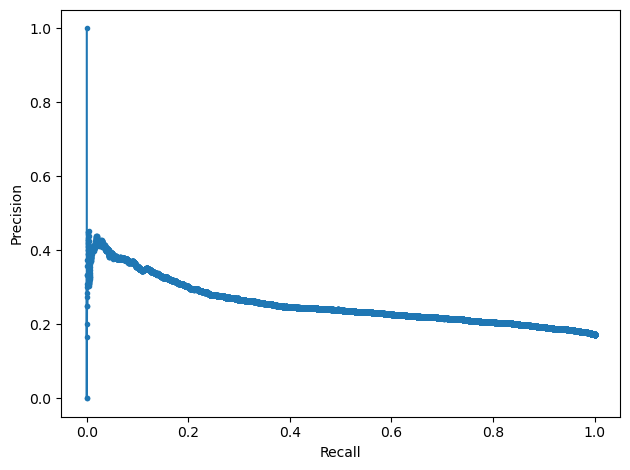

In [16]:
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, preds)

plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
fig = plt.gcf()
plt.tight_layout()

In [17]:
fig.savefig('../output/Figures/CatBoost Basketball Injuries Precision-Recall Curve.svg', format='svg',
            bbox_inches='tight')

In [18]:
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve, CalibrationDisplay

brier_score = brier_score_loss(y_test, preds)
print(f'Brier Score: {brier_score:.4f}')

Brier Score: 0.1407


In [19]:
fig.savefig('../output/Figures/CatBoost Basketball Injuries Calibration Curve.svg', format='svg',
            bbox_inches='tight')

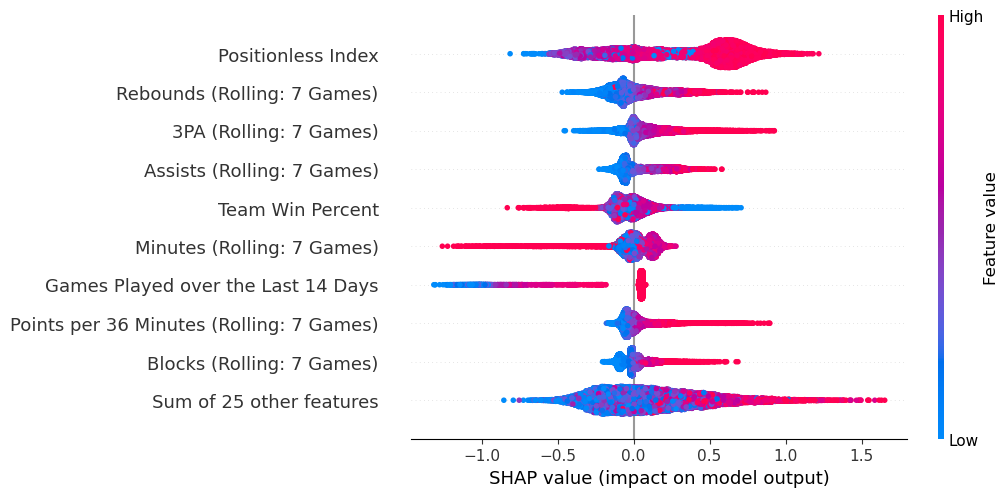

In [20]:
import shap

explainer = shap.TreeExplainer(model)

feature_renaming = {
    "rolling_7g_three_pointers_attempted": '3PA (Rolling: 7 Games)',
    'rolling_7g_USG': 'Usage Rate (Rolling: 7 Games)',
    'positionless_index': 'Positionless Index',
    'rolling_7g_points_per36': 'Points per 36 Minutes (Rolling: 7 Games)',
    'rolling_7g_rebounds': 'Rebounds (Rolling: 7 Games)',
    'winPercent_team': 'Team Win Percent',
    'rolling_7g_minutes': 'Minutes (Rolling: 7 Games)',
    'rolling_7g_blocks': 'Blocks (Rolling: 7 Games)',
    'games_last_14d': 'Games Played over the Last 14 Days',
    'rolling_7g_assists': 'Assists (Rolling: 7 Games)',
    'rolling_3g_minutes': 'Minutes (Rolling: 3 Games)',
    'rolling_7g_assists_per36': 'Assists per 36 Minutes (Rolling: 7 Games)'
}

shap_values = explainer(X_test)

shap_values.feature_names = [feature_renaming[c] if c in feature_renaming else c for c in X_test.columns]

shap.plots.beeswarm(shap_values)

In [21]:
shap.plots.beeswarm(
    shap_values, show=False
)

fig = plt.gcf()

fig.savefig(
    "../output/Figures/CatBoost Basketball Injuries SHAP Summary Plot.svg",
    format="svg",
    bbox_inches="tight"
)

plt.close()

In [22]:
sel_features = ['positionless_index', "rolling_7g_three_pointers_attempted", 
                'winPercent_team', 'rolling_7g_rebounds', 'rolling_7g_blocks', 'rolling_7g_minutes',
                'games_last_14d', 'rolling_7g_assists', 'rolling_7g_points_per36'
                ]
from collections import Counter

df['Injuries'] = df['Injuries'].apply(
    lambda arr: [
        'Sprained ankle' if x in ('Sprained left ankle', 'Sprained right ankle') else x
        for x in arr
    ]
)

df['Injuries'] = df['Injuries'].apply(
    lambda arr: [
        'Sore knee' if x in ('Sore left knee', 'Sore right knee') else x
        for x in arr
    ]
)

df['Injuries'] = df['Injuries'].apply(
    lambda arr: [
        'Sore ankle' if x in ('Sore left ankle', 'Sore right ankle') else x
        for x in arr
    ]
)

df['Injuries'] = df['Injuries'].apply(
    lambda arr: [
        'Knee injury' if x in ('Left knee injury', 'Right knee injury') else x
        for x in arr
    ]
)

injury_counter = Counter()
for arr in df['Injuries']:
    for inj in arr:
        injury_counter[inj]+=1

top_injuries, top_inj_counts = zip(*injury_counter.most_common(5))
print(top_injuries, top_inj_counts)

('Sprained ankle', 'Sore knee', 'Knee injury', 'Sore ankle', 'Back injury') (3930, 2394, 1681, 1230, 670)


In [23]:
for inj in top_injuries:
    df[inj] = df['Injuries'].apply(
        lambda arr: int(inj in arr)
    )
test_targets = df.loc[test_mask, top_injuries].reset_index(drop=True)
shap_vals = {}
aucs = {}

for inj in top_injuries:
    y_inj_train = df.loc[train_mask | val_mask, inj].values
    y_inj_test = test_targets[inj].values

    model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        verbose=0,
        random_seed=42
    )

    model.fit(X_full_train, y_inj_train)
    preds = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, preds)
    aucs[inj] = auc
    
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_test)
    shap_vals[inj] = sv
print(aucs)

{'Sprained ankle': 0.47448009453323947, 'Sore knee': 0.4639368419339289, 'Knee injury': 0.47677398249288594, 'Sore ankle': 0.5021130959409117, 'Back injury': 0.4786032625814955}


In [24]:
from scipy.stats import ttest_1samp

feature_names = list(X_test.columns)
col_position = {f: i for i, f in enumerate(feature_names)}
sel_indices = [col_position[f] for f in sel_features]

z = 1.96

results = {}

for inj in top_injuries:
    sv = shap_vals[inj]
    X_arr = X_test.values
    xshap = X_arr * sv

    res = {}
    for idx, feature in zip(sel_indices, sel_features):
        vals = xshap[:, idx]
        m = vals.mean()
        se = vals.std(ddof=1) / np.sqrt(len(vals))
        lo, hi = m-z*se, m+z*se
        _, p = ttest_1samp(vals, popmean=0)

        res[feature] = {
            'mean': m,
            'low': lo,
            'high': hi,
            'p-val': p
        }

    results[inj] = res

In [25]:
from statsmodels.stats.multitest import multipletests

tests = []
for inj in top_injuries:
    for feature in sel_features:
        tests.append(results[inj][feature]["p-val"])

_, p_adj, _, _ = multipletests(tests, method="fdr_bh")

k = 0
for inj in top_injuries:
    for feature in sel_features:
        results[inj][feature]["p_adj"] = p_adj[k]
        k += 1

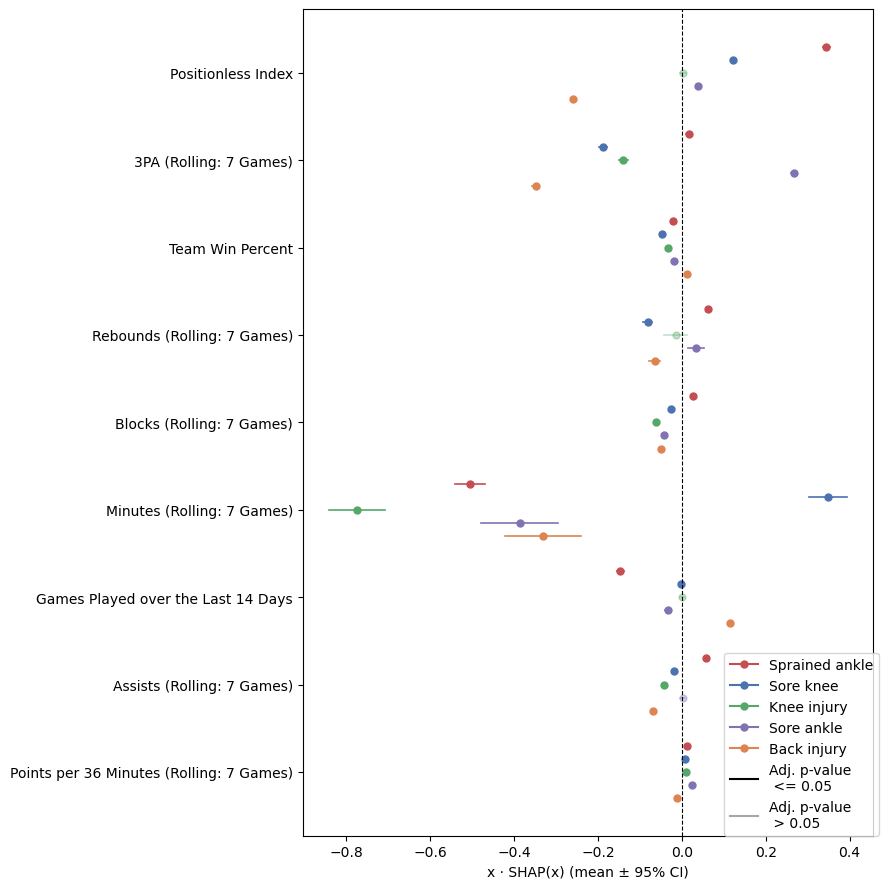

In [ ]:
import matplotlib.lines as mlines

n_features = len(sel_features)
n_inj      = len(top_injuries)
colors = ['#C44E52', '#4C72B0', '#55A868', '#8172B2', '#DD8452']
offsets    = np.linspace(-0.3, 0.3, n_inj)   # vertical jitter per injury

fig, ax = plt.subplots(figsize=(9, 9))

for j, (inj, color) in enumerate(zip(top_injuries, colors)):
    for i, fname in enumerate(sel_features):
        res = results[inj][fname]
        y = i + offsets[j]
        alpha = 1 if res['p_adj'] <= 0.05 else 0.35
        ax.plot([res['low'], res['high']], [y, y], color=color, linewidth=1.2, alpha=alpha)
        ax.plot(res['mean'], y, 'o', color=color, markersize=5, alpha=alpha)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(range(n_features))
ax.set_yticklabels([feature_renaming[c] for c in sel_features])
ax.invert_yaxis()
ax.set_xlabel('x · SHAP(x) (mean ± 95% CI)')

legend_handles = [
    mlines.Line2D([], [], color=c, marker='o', markersize=5, label=inj)
    for inj, c in zip(top_injuries, colors)
]
legend_handles+= [
    mlines.Line2D([], [], color='black', lw=1.5, alpha=1.0,
                  label='Adj. p-value\n <= 0.05'),
    mlines.Line2D([], [], color='black', lw=1.5, alpha=0.35,
                  label='Adj. p-value\n > 0.05'),
]
ax.legend(handles=legend_handles, bbox_to_anchor=(1, 0), loc='lower right', borderaxespad=0)
fig = plt.gcf()

plt.tight_layout()

In [29]:
fig.savefig(
    "../output/Figures/Feature Importance on Common Injury Classes.svg",
    format="svg",
    bbox_inches="tight"
)

plt.close()